In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm
import os
from source.random_walk import generate_head_direction_walk, toroidal_to_solid_angle
from source.plot_tools import activity_map

In [2]:

class ToroidCAN:
    def __init__(self, n = 64, tau = 10e-3, dt = 0.5e-3):
        self.n = n
        self.tau = tau
        self.dt = dt

        self.beta = 0.01 / (n)
        self.gamma = 1.05 * self.beta
        self.a_weight = 1

        l_shift = 2.0
        alpha = 0.037
        self.alpha_x = alpha
        self.alpha_y = alpha

        self.B0 = 1
        self.seed = 0
        self.dir_vectors = {
            "E": np.array([1.0, 0.0]),
            "W": np.array([-1.0, 0.0]),
            "N": np.array([0.0, 1.0]),
            "S": np.array([0.0, -1.0]),
        }
        dir_pattern = np.array([["E", "N"], ["S", "W"]])
        theta_dir = np.tile(dir_pattern, (n // 2, n // 2))

        self.directed_kernels = {}
        self.directed_masks = {}

        for preferred_direction in self.dir_vectors:
            self.directed_kernels[preferred_direction] = np.fft.fft2(
                self.periodic_kernel(
                    n,
                    l_shift=l_shift,
                    e_theta=self.dir_vectors[preferred_direction],
                )
            )
            self.directed_masks[preferred_direction] = theta_dir == preferred_direction
        self.e_theta_x = np.vectorize(lambda d: self.dir_vectors[d][0])(theta_dir)
        self.e_theta_y = np.vectorize(lambda d: self.dir_vectors[d][1])(theta_dir)

        self.s = np.random.uniform(size=(n,n)) * 0.001
        self.s[int(n//2),int(n//2)] = 0.5

    def periodic_kernel(self, n, l_shift=0.0, e_theta=(0.0, 0.0)):
        idx = np.arange(n)
        d = idx - n // 2
        d = np.where(d > n / 2, d - n, d)
        d = np.where(d < -n / 2, d + n, d)
        dx, dy = np.meshgrid(d, d, indexing="ij")

        sx = dx - l_shift * e_theta[0]
        sy = dy - l_shift * e_theta[1]
        r2 = sx**2 + sy**2

        K = self.a_weight * np.exp(-self.gamma * r2) - np.exp(-self.beta * r2)
        K = np.fft.ifftshift(K)
        return K

    def recurrent_input(self, s):
        rec_input = np.zeros_like(s)
        for dir in self.dir_vectors:
            rec_input += np.real(
                np.fft.ifft2(np.fft.fft2(self.directed_masks[dir] * s) * self.directed_kernels[dir])
            )
        return rec_input

    def feedforward_input(self, vx, vy):
        return self.B0 * (1.0 +  self.alpha_x * self.e_theta_x * vx + self.alpha_y * self.e_theta_y * vy)

    def step(self, vx = 0, vy = 0):
        total_input = self.recurrent_input(self.s) + self.feedforward_input(vx, vy)
        self.s =  self.s + (self.dt / self.tau) * (-self.s + np.maximum(total_input, 0.0))

    def warm_up(self, tol = 1e-6,max_iter = 100000):
        prev_net_state = self.s.copy()
        self.step()
        step = 0
        while(np.max(np.abs(prev_net_state - self.s)) > tol):
        #for _ in range(10000):
            prev_net_state = self.s.copy()
            self.step() 
            if step >= max_iter:
                raise RuntimeError("Exceed the prescribed recursion depth")
            step += 1
        print(f"Ran warm up for {step} steps")


Ran warm up for 12598 steps


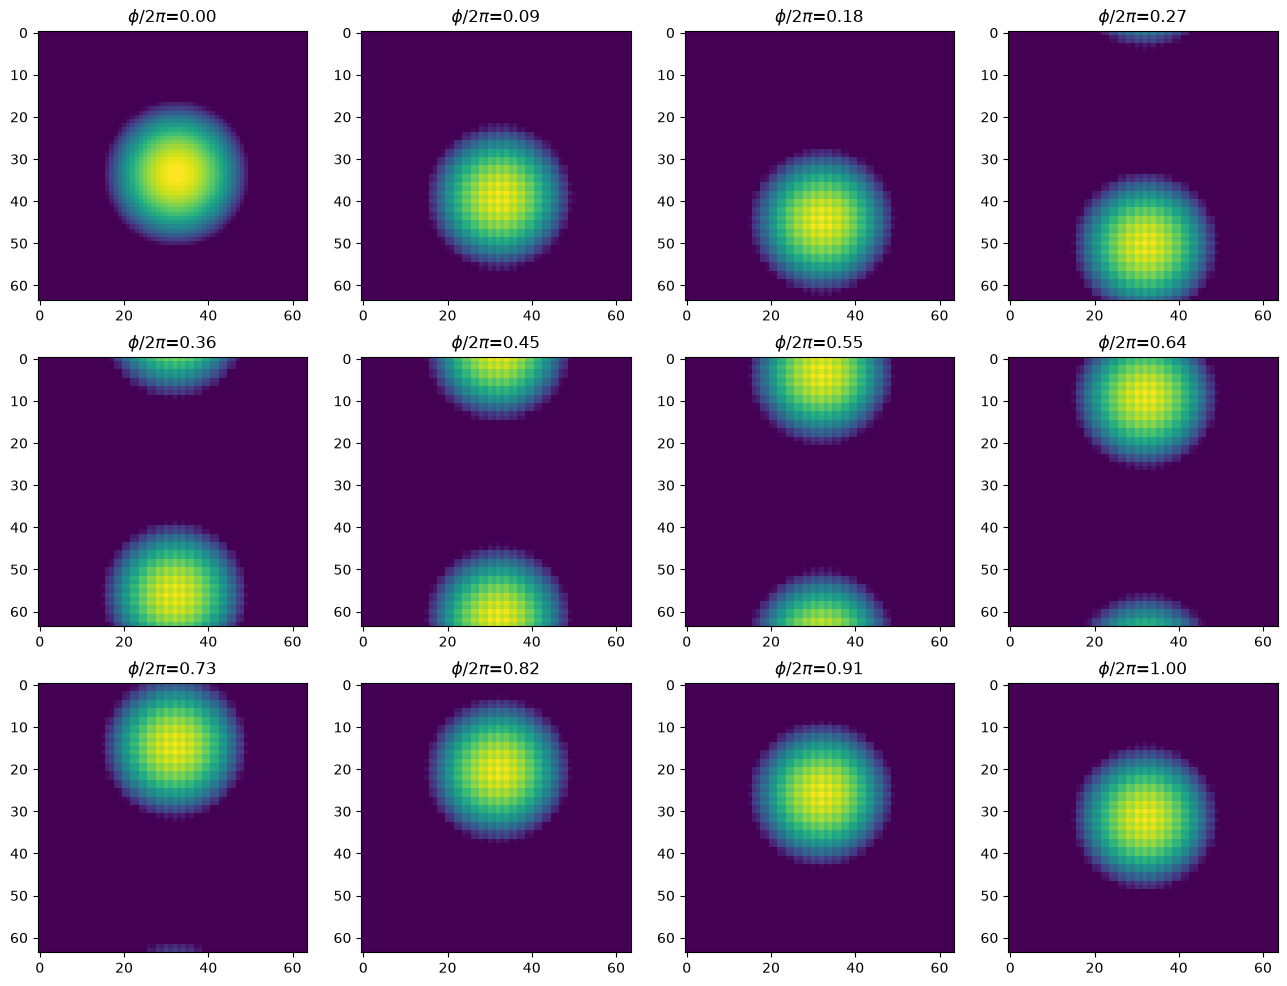

In [3]:
## Simulation parameters:
n_min_plots = 10
dt = 0.5e-3

net = ToroidCAN(n = 64, dt=dt)
net.warm_up()
ncols = np.int64(np.ceil(np.sqrt(n_min_plots)))
nrows = np.int64(np.ceil(n_min_plots / ncols))
n_plots = nrows * ncols
fig, ax = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
ax = ax.flatten()
phi = 0
omega = 1
n_steps = int(2 * np.pi / omega / dt)
records = np.linspace(0, n_steps - 1, n_plots, dtype=int)
plot_counter = 0
time = 0
for step_iter in range(n_steps):
    if step_iter == records[plot_counter]:
        ax[plot_counter].imshow(net.s)
        ax[plot_counter].set_title(f"$\\phi/2\\pi$={phi/(2*np.pi):.2f}")
        plot_counter += 1
    net.step(omega, 0)
    time += dt
    phi += omega * dt


In [4]:
T = 4000
dt = 0.5e-3
n = 64
save_dir = "simulation_data"

recorded_cells = [(0,0),(32,32)]

direction, turn_velocity, time =  generate_head_direction_walk(T, dt)
n_steps = time.shape[0]
net = ToroidCAN(n = n, dt=dt)
net.warm_up()
recording = np.zeros((n_steps,len(recorded_cells)))
for step_iter in tqdm.tqdm(range(n_steps)):
    recording[step_iter] = np.array([net.s[cell_index] for cell_index in recorded_cells])
    net.step(*turn_velocity[step_iter])






Ran warm up for 8151 steps


100%|██████████| 8000000/8000000 [56:23<00:00, 2364.33it/s]  


In [27]:
azimuth_activity_map, edges = activity_map(direction[:,0], recording[:,0])

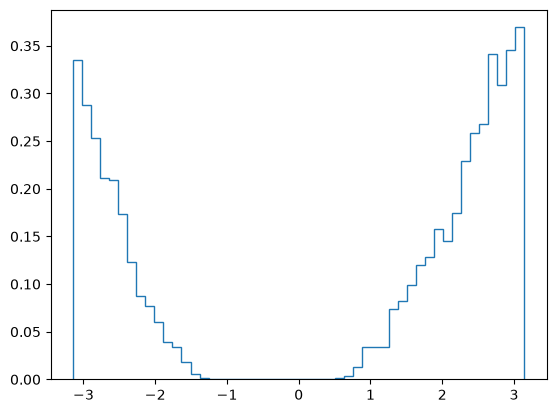

In [28]:
plt.stairs(values = azimuth_activity_map,edges = edges[0] )

In [8]:
from importlib import reload
import source.random_walk as random_walk
reload(random_walk)

direction = random_walk.toroidal_to_solid_angle(direction)

os.makedirs(save_dir, exist_ok=True)
np.save(os.path.join(save_dir,"3d_hd_recording.npy"),recording)
np.save(os.path.join(save_dir,"3d_hd_direction.npy"), direction)
np.save(os.path.join(save_dir,"3d_hd_turn_velocity.npy"), turn_velocity)
np.save(os.path.join(save_dir,"3d_hd_time.npy"),time)


In [9]:
recording = np.load(os.path.join(save_dir,"3d_hd_recording.npy"))
direction = np.load(os.path.join(save_dir,"3d_hd_direction.npy"))
turn_velocity = np.load(os.path.join(save_dir,"3d_hd_turn_velocity.npy"))
time = np.load(os.path.join(save_dir,"3d_hd_time.npy"))

In [16]:
direction[:,1].max()

np.float64(3.1415923736223923)